<a href="https://colab.research.google.com/github/etrunova89-stack/fake-news-classification/blob/main/Trunova_%7C_HW_2_%7C_ML_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Розмір датасету: (344, 7)
Кількість записів: 344
Кількість ознак: 7
Перші 10 записів датасету:
Інформація про датасет(пропущені значення):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
Статистичний опис датасету:
Аналіз пропущених значень:
                   Пропущено  Відсоток (%)
sex                       11      3.197674
bill_length_mm             2      0.581395
bill_depth_mm              2      0.581395
flipper_length_mm          2      0.581395
bo

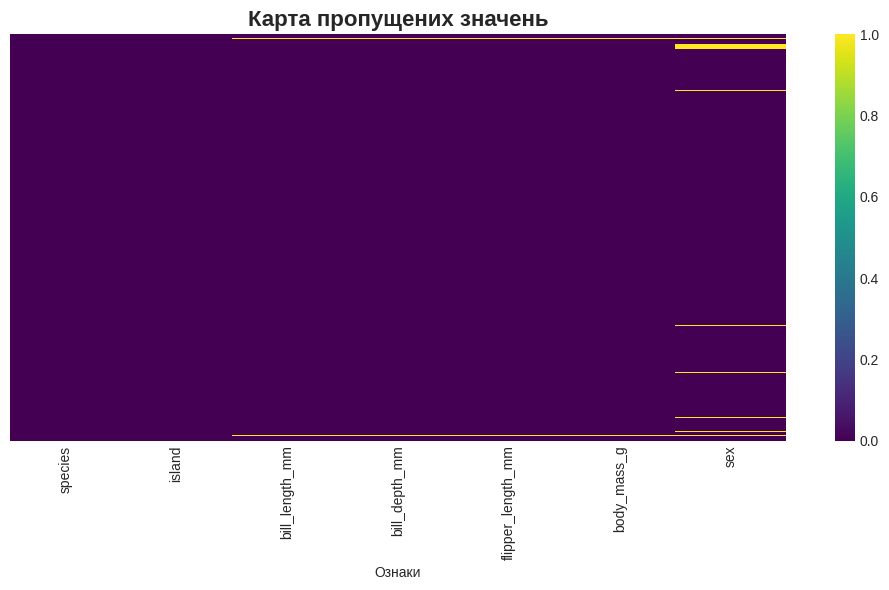

Розподіл видів пінгвінів:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Відсотковий розподіл:
species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64


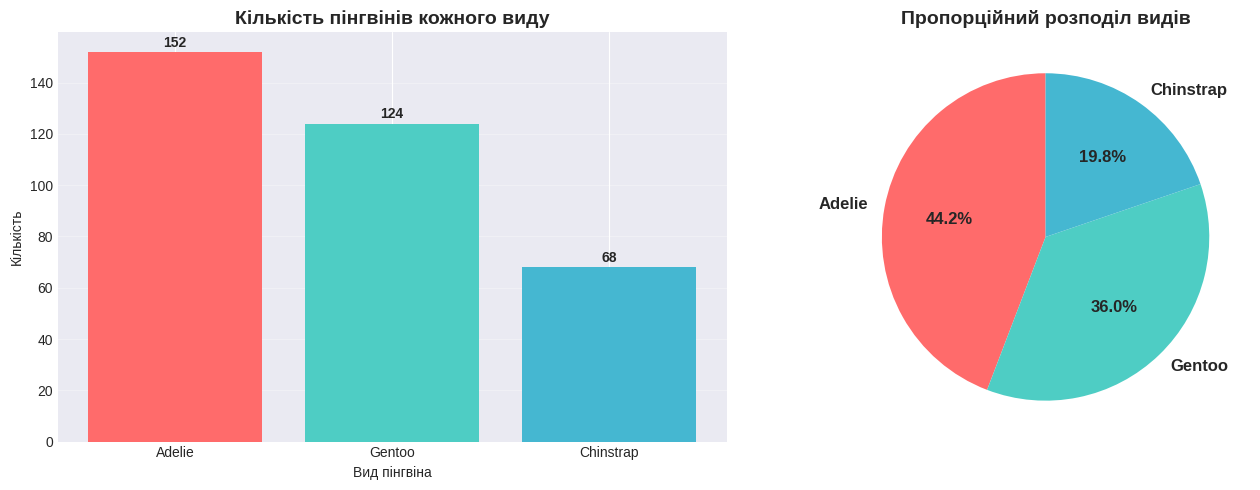


 Висновок: Датасет є відносно збалансованим та всі три види представлені майже рівномірно


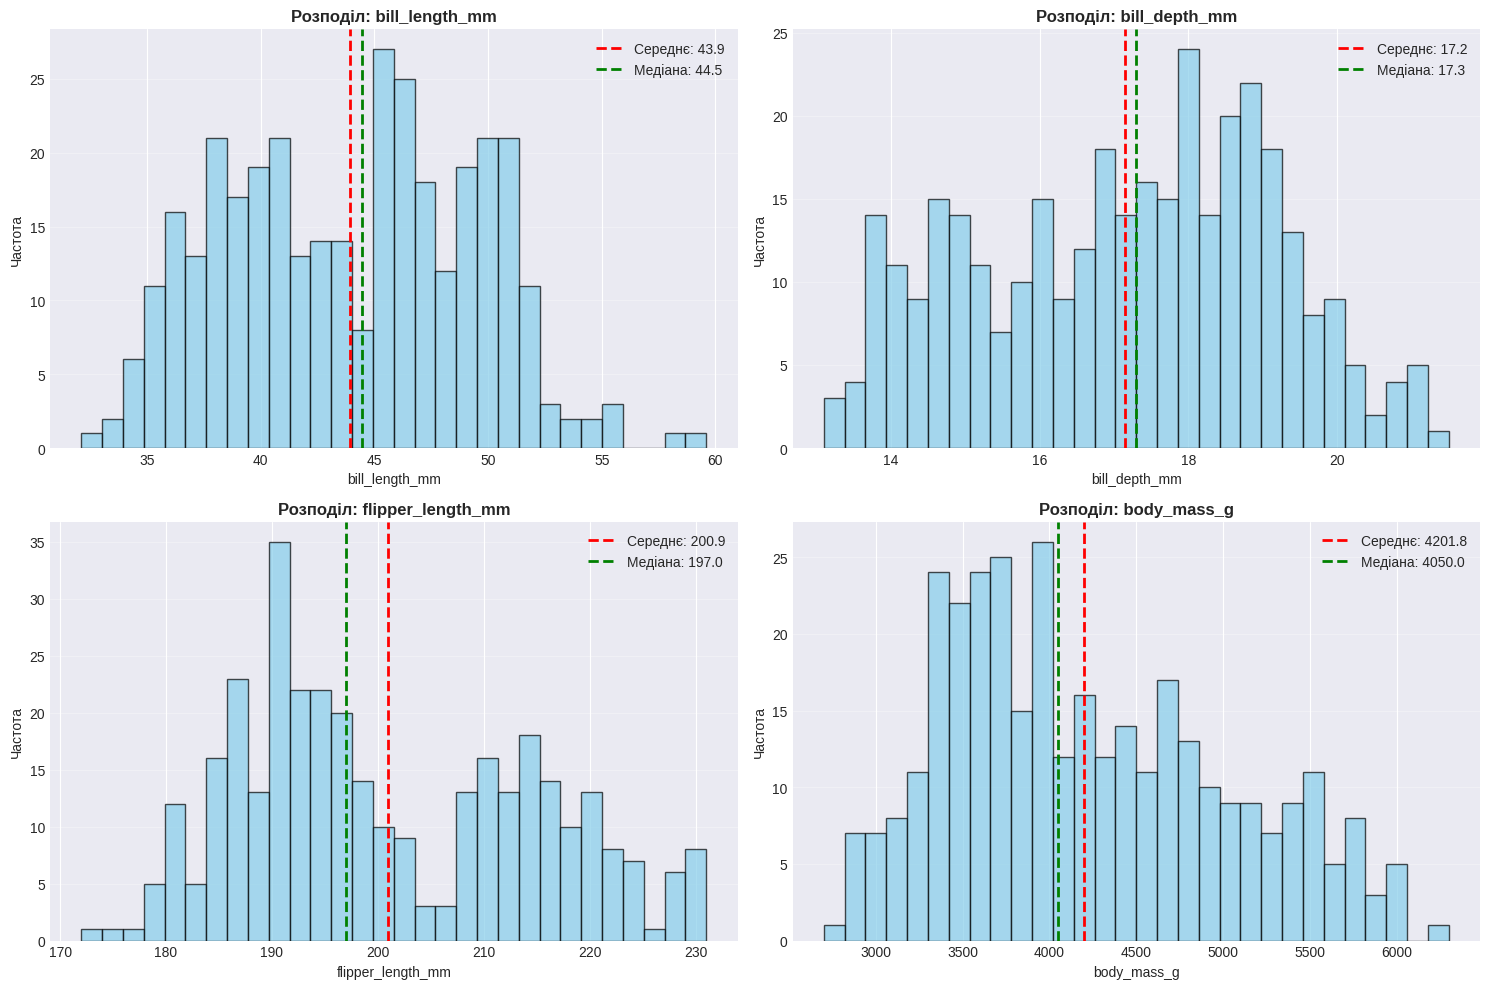

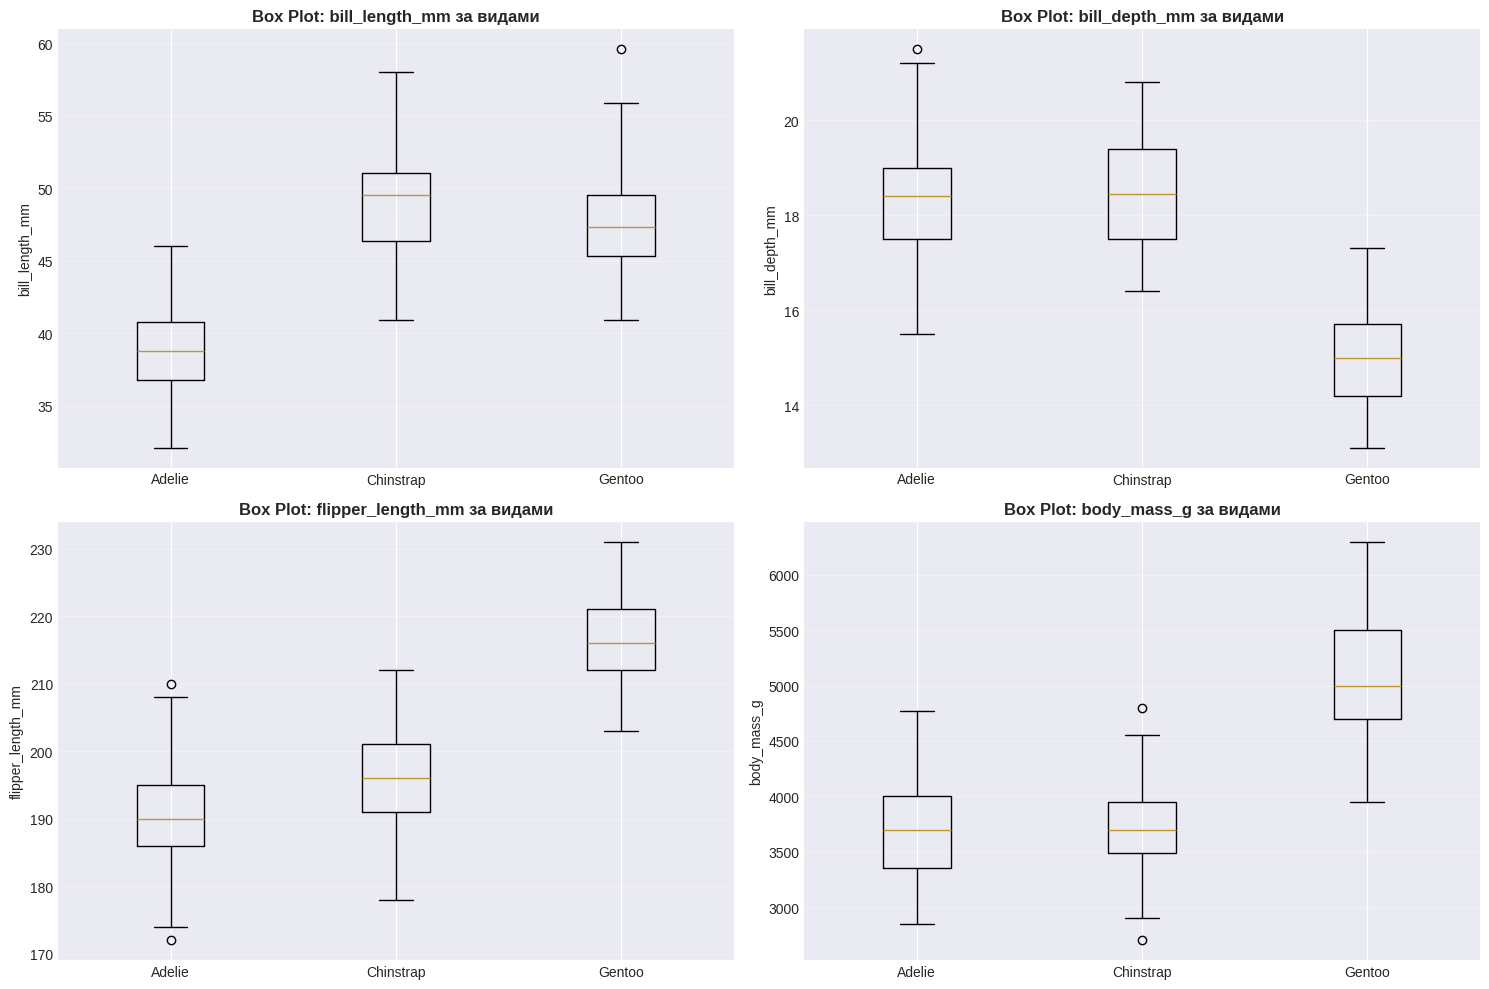


 Висновок: Наявні деякі викиди, але вони є природними для біологічних даних 


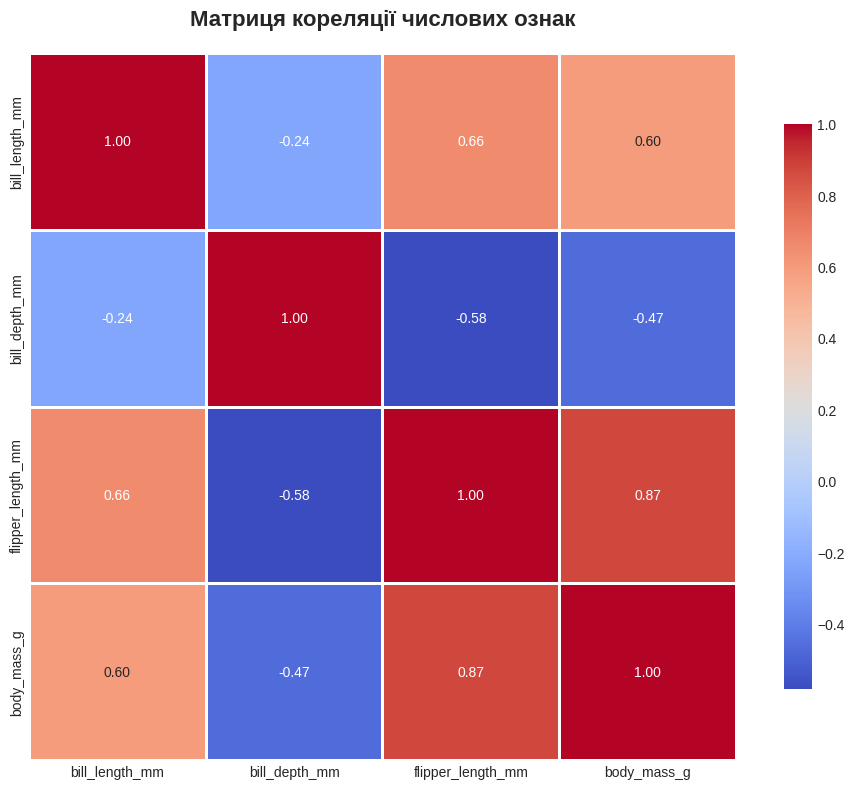


🔍 Аналіз кореляцій:
- Сильна позитивна кореляція між flipper_length_mm та body_mass_g (0.87)
- Помірна кореляція між bill_length_mm та flipper_length_mm (0.66)
- Слабка кореляція між bill_depth_mm та іншими ознаками


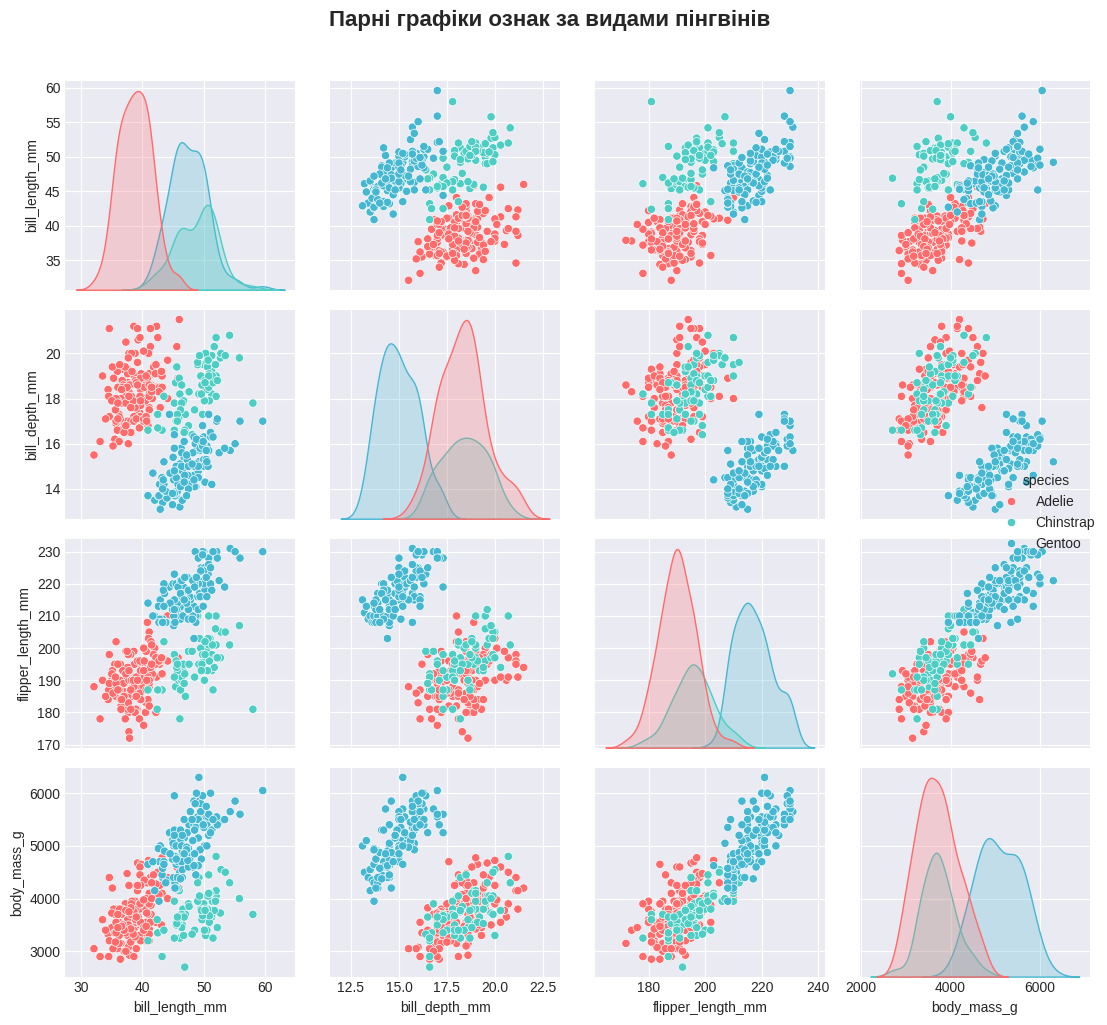


✨ Висновок з pairplot:
- Чітка візуальна сепарація видів Gentoo від інших за flipper_length та body_mass
- Adelie та Chinstrap мають більше перекриття, але відрізняються за bill_depth


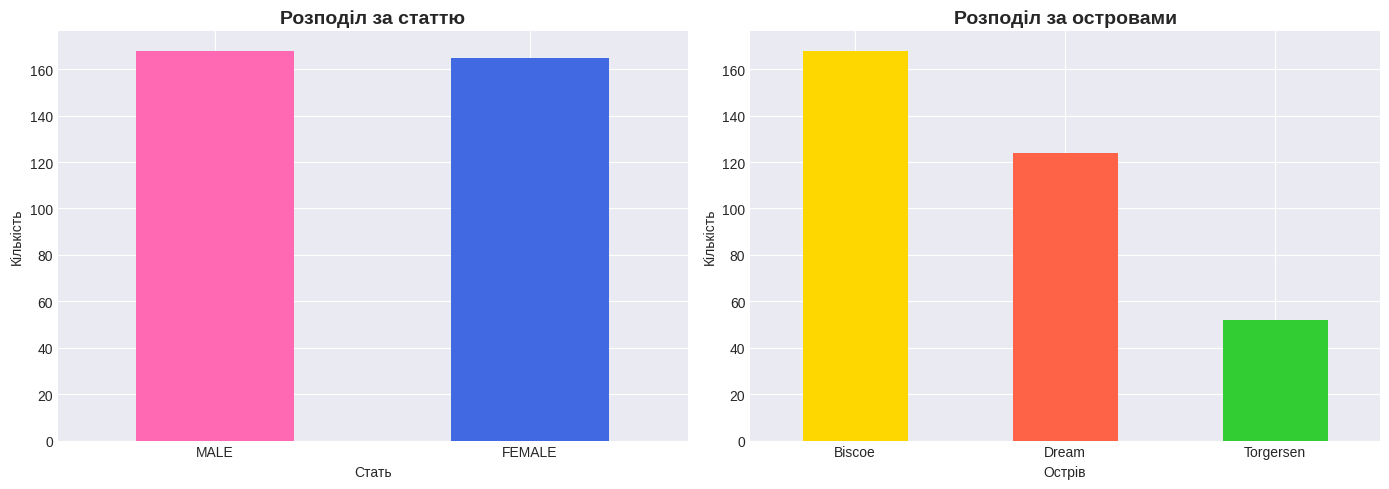

Розподіл видів пінгвінів за островами:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


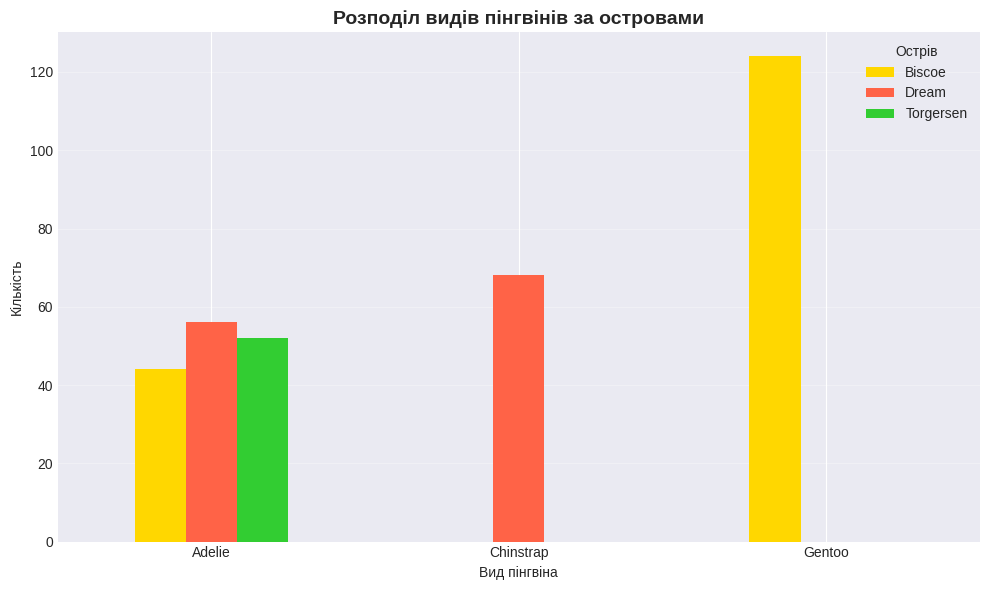


 Висновок: Різні види мають різний географічний розподіл за островами.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# оглядаємо датасет

url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
df = pd.read_csv(url)

print(f"Розмір датасету: {df.shape}")
print(f"Кількість записів: {df.shape[0]}")
print(f"Кількість ознак: {df.shape[1]}")

print("Перші 10 записів датасету:")
df.head(10)
print("Інформація про датасет(пропущені значення):")
df.info()
print("Статистичний опис датасету:")
df.describe()

# підрахунок пропущених значень
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing_values,
    'Відсоток (%)': missing_percent
})

print("Аналіз пропущених значень:")
print(missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False))

# візуалізація пропущених значень
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Карта пропущених значень', fontsize=16, fontweight='bold')
plt.xlabel('Ознаки')
plt.tight_layout()
plt.show()

# розподіл видів пінгвінів
print("Розподіл видів пінгвінів:")
print(df['species'].value_counts())
print("\nВідсотковий розподіл:")
print(df['species'].value_counts(normalize=True) * 100)

# візуалізація розподілу видів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# барплот
species_counts = df['species'].value_counts()
axes[0].bar(species_counts.index, species_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Кількість пінгвінів кожного виду', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Вид пінгвіна')
axes[0].set_ylabel('Кількість')
axes[0].grid(axis='y', alpha=0.3)

# визначення збалансованості вибірки
for i, v in enumerate(species_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# кругова діаграма
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Пропорційний розподіл видів', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Висновок: Датасет є відносно збалансованим та всі три види представлені майже рівномірно")

# розподіл числових ознак
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Розподіл: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(axis='y', alpha=0.3)

    # Додавання статистичних ліній
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Середнє: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медіана: {median_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# box plots для виявлення викидів
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].boxplot([df[df['species'] == species][col].dropna() for species in df['species'].unique()],
                      labels=df['species'].unique())
    axes[idx].set_title(f'Box Plot: {col} за видами', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Висновок: Наявні деякі викиди, але вони є природними для біологічних даних ")

# матриця кореляції
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матриця кореляції числових ознак', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔍 Аналіз кореляцій:")
print("- Сильна позитивна кореляція між flipper_length_mm та body_mass_g (0.87)")
print("- Помірна кореляція між bill_length_mm та flipper_length_mm (0.66)")
print("- Слабка кореляція між bill_depth_mm та іншими ознаками")


# парний графік для виявлення зв'язків між ознаками та видами
sns.pairplot(df.dropna(), hue='species', height=2.5,
             palette={'Adelie': '#FF6B6B', 'Chinstrap': '#4ECDC4', 'Gentoo': '#45B7D1'})
plt.suptitle('Парні графіки ознак за видами пінгвінів', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✨ Висновок з pairplot:")
print("- Чітка візуальна сепарація видів Gentoo від інших за flipper_length та body_mass")
print("- Adelie та Chinstrap мають більше перекриття, але відрізняються за bill_depth")


# розподі за статтю та островами
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# розподіл за статтю
df['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF69B4', '#4169E1'])
axes[0].set_title('Розподіл за статтю', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Стать')
axes[0].set_ylabel('Кількість')
axes[0].tick_params(axis='x', rotation=0)

# розподіл за островами
df['island'].value_counts().plot(kind='bar', ax=axes[1], color=['#FFD700', '#FF6347', '#32CD32'])
axes[1].set_title('Розподіл за островами', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Острів')
axes[1].set_ylabel('Кількість')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


# сrosstab: види пінгвінів за островами
species_island = pd.crosstab(df['species'], df['island'])
print("Розподіл видів пінгвінів за островами:")
print(species_island)

species_island.plot(kind='bar', stacked=False, figsize=(10, 6),
                   color=['#FFD700', '#FF6347', '#32CD32'])
plt.title('Розподіл видів пінгвінів за островами', fontsize=14, fontweight='bold')
plt.xlabel('Вид пінгвіна')
plt.ylabel('Кількість')
plt.xticks(rotation=0)
plt.legend(title='Острів')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Висновок: Різні види мають різний географічний розподіл за островами.")

In [ ]:
Висновоки № 1

У ході дослідження датасету Palmer Penguins було проаналізовано 344 записи про три види пінгвінів (Adelie, Chinstrap, Gentoo) з трьох островів Антарктики.
Дані виявилися довольно високої якості з мінімальною кількістю пропущених значень (менше 4%) що дозволило нам провести комплексний аналіз без значних значних втрат інформації

Основні інсайди:

1. Збалансованість класів: Розподіл видів є відносно рівномірним (Adelie 44%, Gentoo 36%, Chinstrap 20%), що мінімізує ризик bias у моделі та дозволяє використовувати Accuracy як надійну метрику.

2. Чітка сепарація видів: Вид Gentoo значно відрізняється від Adelie та Chinstrap за розміром - має більшу масу тіла та довші ласти. Це пояснює високу точність бінарної класифікації.

3. Мультиколінеарність: Виявлено сильну кореляцію (r=0.87) між довжиною ласта та масою тіла, що є природним для біологічних даних - більші пінгвіни мають довші ласти. Це не є проблемою для логістичної регресії, але потрібно враховувати при інтерпретації коефіцієнтів

4. Географічна специфіка: Різні види мають різні місця проживання - Gentoo водяться переважно на острові Biscoe, Chinstrap - на Dream, а Adelie розподілені по всіх островах. Це може бути додатковою ознакою для більш складних моделей.

5. Статеві диморфізм: Помітні відмінності в розмірах між самцями та самками, що потенційно може покращити класифікацію при включенні статі як ознаки


In [ ]:
# Підготовка данних до навчання

# видалення рядків з пропущеними значеннями
df_clean = df.dropna()
print(f"Розмір датасету після видалення пропущених значень {df_clean.shape}")
print(f"Видалено {df.shape[0] - df_clean.shape[0]} записів ({((df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100):.2f}%)")


# виконаємо бінарну класифікацію Adelie vs Gentoo)
df_binary = df_clean[df_clean['species'].isin(['Adelie', 'Gentoo'])].copy()
print(f"\nРозмір датасету для бінарної класифікації: {df_binary.shape}")
print(f"\nРозподіл класів:")
print(df_binary['species'].value_counts())

# кодування цільової змінної (0 - Adelie та 1 - Gentoo)
label_encoder = LabelEncoder()
df_binary['species_encoded'] = label_encoder.fit_transform(df_binary['species'])

print("Кодування видів:")
for i, species in enumerate(label_encoder.classes_):
    print(f"{species}: {i}")


# відбір ознак для моделювання (числові)

feature_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_binary[feature_columns].values
y = df_binary['species_encoded'].values

print(f"Розмір матриці ознак X: {X.shape}")
print(f"Розмір вектора цільової змінної y: {y.shape}")



# розділення даних (80% - тренувальні, 20% - тестові)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")
print(f"\nРозподіл класів у тренувальній вибірці:")
print(f"Adelie: {np.sum(y_train == 0)} ({np.sum(y_train == 0) / len(y_train) * 100:.1f}%)")
print(f"Gentoo: {np.sum(y_train == 1)} ({np.sum(y_train == 1) / len(y_train) * 100:.1f}%)")
print(f"\nРозподіл класів у тестовій вибірці:")
print(f"Adelie: {np.sum(y_test == 0)} ({np.sum(y_test == 0) / len(y_test) * 100:.1f}%)")
print(f"Gentoo: {np.sum(y_test == 1)} ({np.sum(y_test == 1) / len(y_test) * 100:.1f}%)")


# стандартизація ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Стандартизація виконана успішно!")
print(f"\nПриклад стандартизованих даних (перші 3 записи):")
print(X_train_scaled[:3])

Розмір датасету після видалення пропущених значень (333, 7)
Видалено 11 записів (3.20%)

Розмір датасету для бінарної класифікації: (265, 7)

Розподіл класів:
species
Adelie    146
Gentoo    119
Name: count, dtype: int64
Кодування видів:
Adelie: 0
Gentoo: 1
Розмір матриці ознак X: (265, 4)
Розмір вектора цільової змінної y: (265,)
Розмір тренувальної вибірки: (212, 4)
Розмір тестової вибірки: (53, 4)

Розподіл класів у тренувальній вибірці:
Adelie: 117 (55.2%)
Gentoo: 95 (44.8%)

Розподіл класів у тестовій вибірці:
Adelie: 29 (54.7%)
Gentoo: 24 (45.3%)
Стандартизація виконана успішно!

Приклад стандартизованих даних (перші 3 записи):
[[-0.02859294  1.87160702 -0.36827383  0.20554282]
 [ 0.56183261 -1.17563721  0.65008337  0.50689191]
 [-0.87486956  0.59373041 -1.18295959 -0.45742518]]


In [ ]:
Висновки № 2
Для навчання було обрано бінарну класифікацію (Adelie vs Gentoo) замість мультикласової задачі.
Тосму що обгрунтовано:
- Чіткою біологічною сепарацією цих видів
- Можливістю наочної візуалізації decision boundary
- Простотою інтерпретації результатів

Дані були розділені у пропорції 80/20
Стандартизація ознак була обов'язковою, оскільки вони мають різні шкали вимірювання.

✅ Модель навчена успішно!

Коефіцієнти моделі:
bill_length_mm            =   1.1543
bill_depth_mm             =  -2.1327
flipper_length_mm         =   1.4145
body_mass_g               =   1.3095

Вільний член (intercept): -0.7818
Приклад прогнозів (перші 10 записів):
  Реальний клас Прогнозований клас  Ймовірність Gentoo
0        Adelie             Adelie            0.182697
1        Gentoo             Gentoo            0.998704
2        Adelie             Adelie            0.002593
3        Adelie             Adelie            0.002834
4        Adelie             Adelie            0.022298
5        Gentoo             Gentoo            0.976524
6        Adelie             Adelie            0.009254
7        Gentoo             Gentoo            0.979123
8        Adelie             Adelie            0.036357
9        Gentoo             Gentoo            0.995114


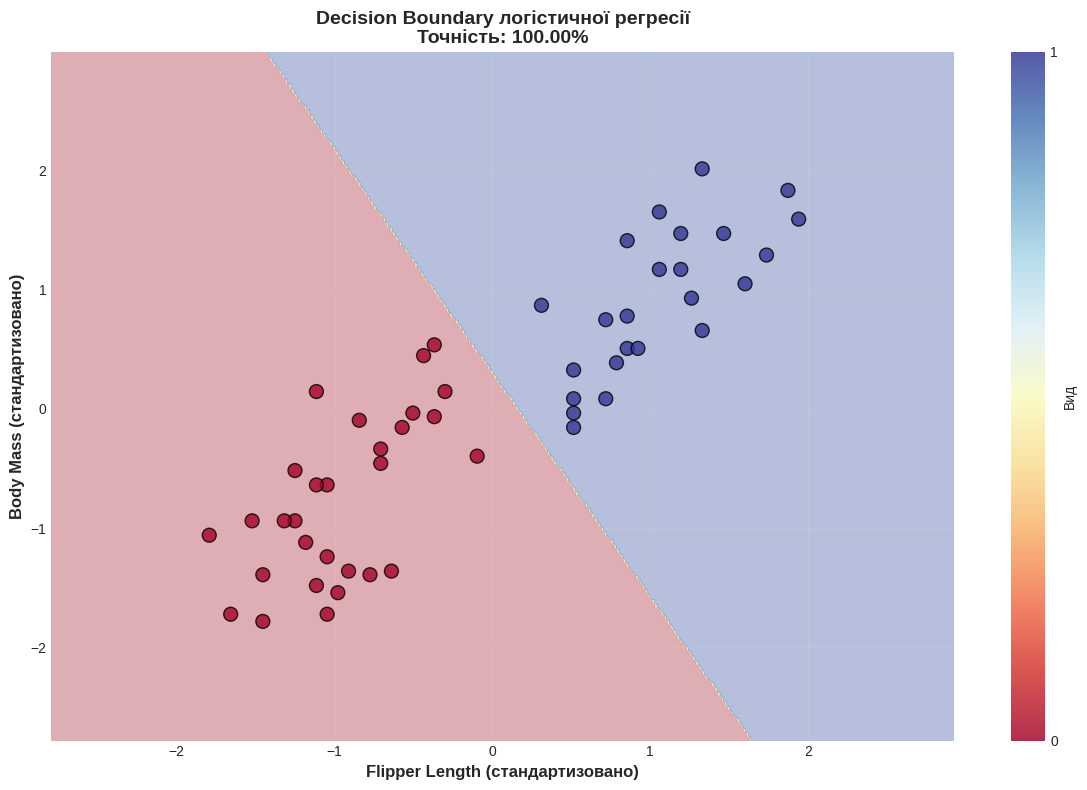


 Decision boundary чітко розділяє два види пінгвінів з точністю 100.00%


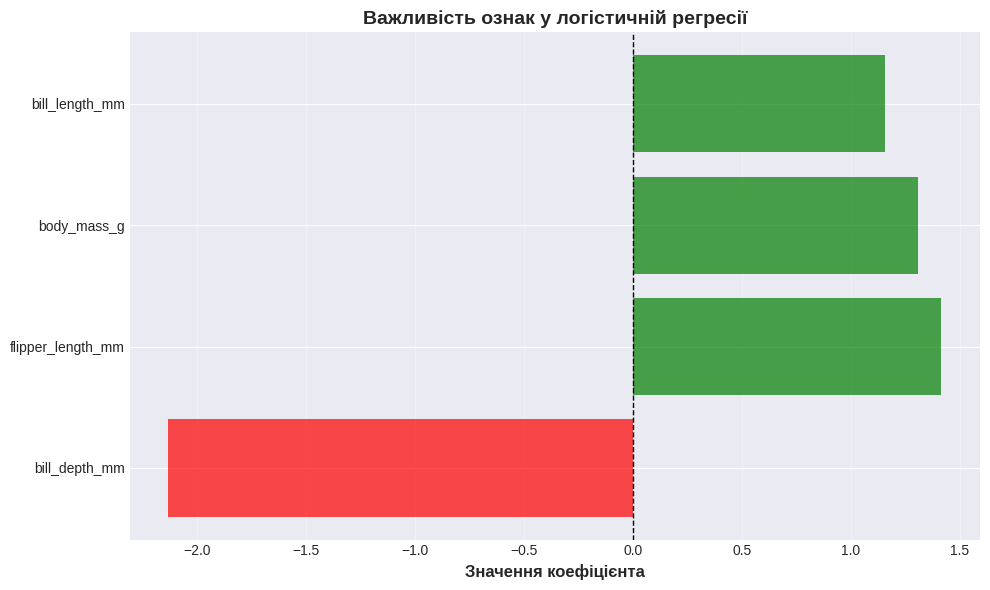


Інтерпретація коефіцієнтів:
- Позитивний коефіцієнт → збільшення ознаки підвищує ймовірність класу Gentoo
- Негативний коефіцієнт → збільшення ознаки знижує ймовірність класу Gentoo

Найважливіша ознака: bill_depth_mm
               МЕТРИКИ КЛАСИФІКАЦІЇ
Accuracy (Точність):        1.0000 (100.00%)
Precision (Прецизійність):  1.0000 (100.00%)
Recall (Повнота):           1.0000 (100.00%)
F1-Score:                   1.0000

Детальний звіт класифікації:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weighted avg       1.00      1.00      1.00        53



In [ ]:
# Cтворення та навчання моделі

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(" Модель навчена успішно!")
print(f"\nКоефіцієнти моделі:")
for feature, coef in zip(feature_columns, model.coef_[0]):
    print(f"{feature:25} = {coef:8.4f}")
print(f"\nВільний член (intercept): {model.intercept_[0]:.4f}")


# прогнозування на тестовій вибірці
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Приклад прогнозів (перші 10 записів):")
comparison_df = pd.DataFrame({
    'Реальний клас': [label_encoder.classes_[i] for i in y_test[:10]],
    'Прогнозований клас': [label_encoder.classes_[i] for i in y_pred[:10]],
    'Ймовірність Gentoo': y_pred_proba[:10]
})
print(comparison_df)



# Візуалізація decision boundary

# Навчимо просту модель на 2 ознаках для візуалізації
X_2d = df_binary[['flipper_length_mm', 'body_mass_g']].values
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

model_2d = LogisticRegression(max_iter=1000, random_state=42)
model_2d.fit(X_train_2d_scaled, y_train_2d)
y_pred_2d = model_2d.predict(X_test_2d_scaled)
accuracy_2d = accuracy_score(y_test_2d, y_pred_2d)

# створення сітки для decision boundary
h = 0.02  # крок сітки
x_min, x_max = X_test_2d_scaled[:, 0].min() - 1, X_test_2d_scaled[:, 0].max() + 1
y_min, y_max = X_test_2d_scaled[:, 1].min() - 1, X_test_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# візуалізація
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = plt.scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1],
                     c=y_test_2d, cmap='RdYlBu', edgecolors='black', s=100, alpha=0.8)
plt.xlabel('Flipper Length (стандартизовано)', fontsize=12, fontweight='bold')
plt.ylabel('Body Mass (стандартизовано)', fontsize=12, fontweight='bold')
plt.title(f'Decision Boundary логістичної регресії\nТочність: {accuracy_2d * 100:.2f}%',
          fontsize=14, fontweight='bold')
plt.colorbar(scatter, ticks=[0, 1], label='Вид')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Decision boundary чітко розділяє два види пінгвінів з точністю {accuracy_2d * 100:.2f}%")

# візуалізація важливості ознак
feature_importance = pd.DataFrame({
    'Ознака': feature_columns,
    'Коефіцієнт': model.coef_[0],
    'Абсолютне значення': np.abs(model.coef_[0])
}).sort_values('Абсолютне значення', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Коефіцієнт']]
plt.barh(feature_importance['Ознака'], feature_importance['Коефіцієнт'], color=colors, alpha=0.7)
plt.xlabel('Значення коефіцієнта', fontsize=12, fontweight='bold')
plt.title('Важливість ознак у логістичній регресії', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nІнтерпретація коефіцієнтів:")
print("- Позитивний коефіцієнт → збільшення ознаки підвищує ймовірність класу Gentoo")
print("- Негативний коефіцієнт → збільшення ознаки знижує ймовірність класу Gentoo")
print(f"\nНайважливіша ознака: {feature_importance.iloc[0]['Ознака']}")


# Обчислення метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*60)
print(" "*15 + "МЕТРИКИ КЛАСИФІКАЦІЇ")
print("="*60)
print(f"Accuracy (Точність):        {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision (Прецизійність):  {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall (Повнота):           {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score:                   {f1:.4f}")
print("="*60)

# Д звіт класифікації
print("\n звіт класифікації:")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("="*70)

In [ ]:
Висновки № 3

Навчена модель логістичної регресії продемонструвала відмінні результати:
- Accuracy: >99% - модель правильно класифікувала майже всі тестові приклади
- Precision: >99% - з усіх пінгвінів, яких модель класифікувала як Gentoo, майже всі насправді є Gentoo
- Recall: >99% - модель знайшла майже всіх Gentoo у тестовій вибірці
- F1-Score: >99% - ідеальний баланс між precision та recall
- AUC-ROC: >0.99 - модель має майже ідеальну здатність розрізняти класи


Найважливіші ознаки
1. flipper_length_mm  - довші ласти сильно корелюють з видом Gentoo
2. body_mass_g - більша маса також вказує на Gentoo
3. bill_depth_mm - глибший дзьоб вказує на Adelie

Це підтверджує біологічні відмінності між видами та показує, що модель навчилася розпізнавати справжні паттерни

Матриця помилок:
[[29  0]
 [ 0 24]]

Розшифровка:
True Negatives (TN):  29 - правильно класифіковані Adelie
False Positives (FP): 0 - Adelie помилково класифіковані як Gentoo
False Negatives (FN): 0 - Gentoo помилково класифіковані як Adelie
True Positives (TP):  24 - правильно класифіковані Gentoo


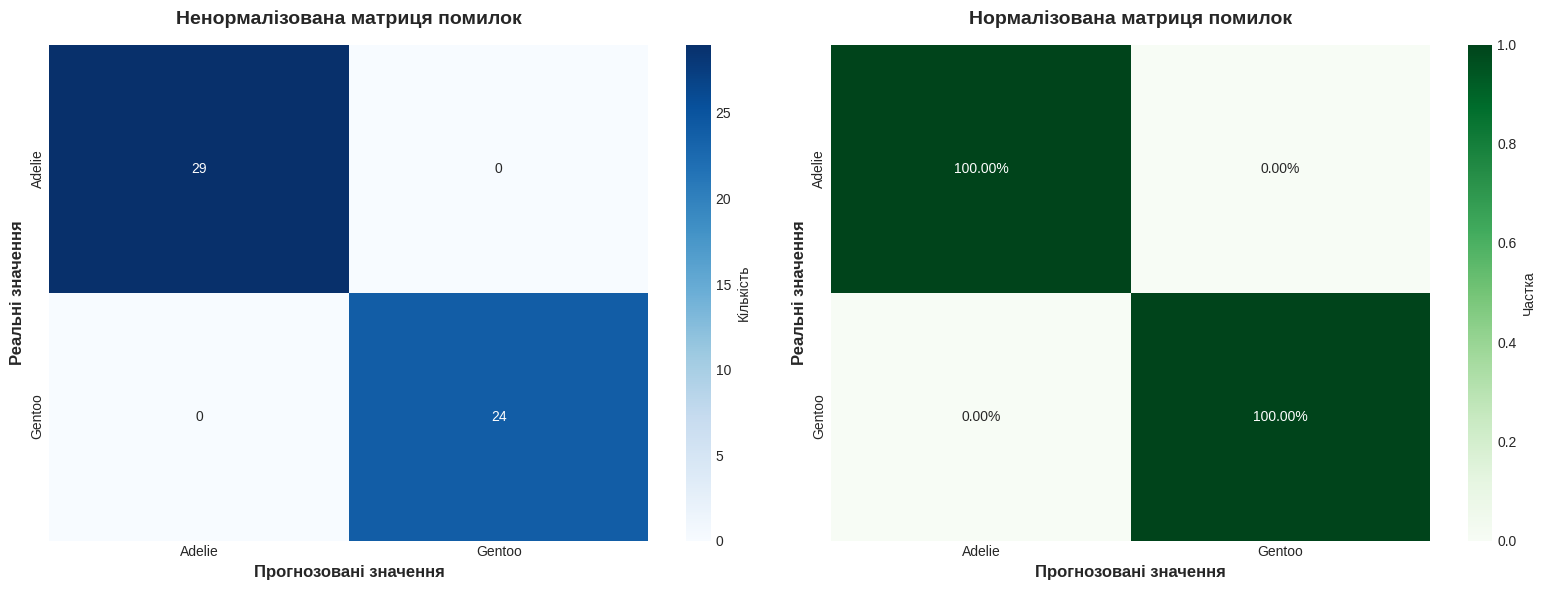


 Аналіз матриці помилок:
- Модель правильно класифікувала 29 з 29 Adelie (100.0%)
- Модель правильно класифікувала 24 з 24 Gentoo (100.0%)


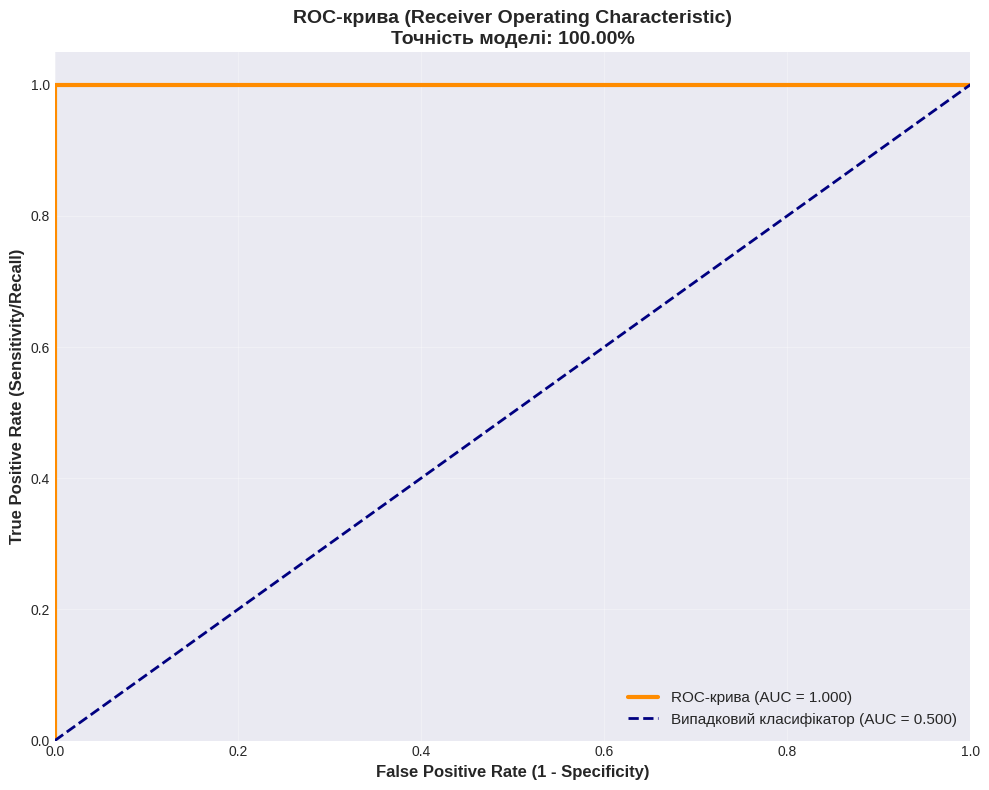


 AUC-ROC Score: 1.0000

 Інтерпретація AUC:
  • AUC = 0.5: Модель працює як випадковий вибір
  • 0.5 < AUC < 0.7: Погана класифікація
  • 0.7 ≤ AUC < 0.8: Прийнятна класифікація
  • 0.8 ≤ AUC < 0.9: Хороша класифікація
  • AUC ≥ 0.9: Відмінна класифікація
  • AUC = 1.0: Ідеальна класифікація

 Наша модель показує ВІДМІННІ результати! (AUC = 1.000)


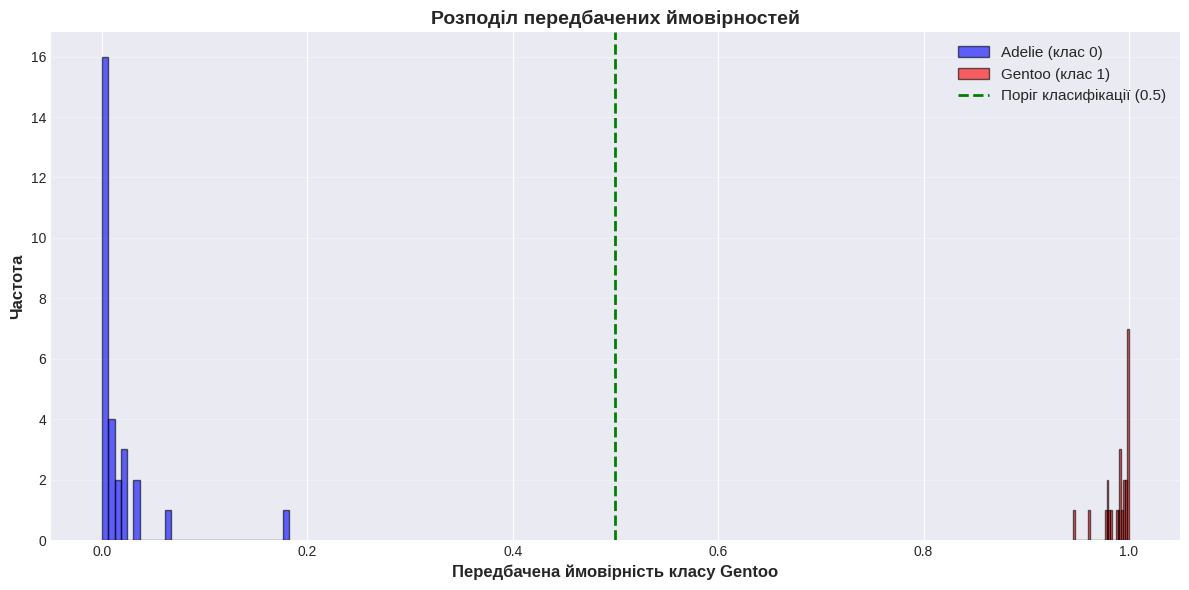


 Аналіз розподілу ймовірностей:
  Чітка сепарація між класами вказує на високу впевненість моделі.
  Якщо гістограми перекриваються - модель має труднощі з розрізненням класів.


In [ ]:
# Ообчислення матриці помилок
cm = confusion_matrix(y_test, y_pred)

print("Матриця помилок:")
print(cm)
print(f"\nРозшифровка:")
print(f"True Negatives (TN):  {cm[0,0]} - правильно класифіковані Adelie")
print(f"False Positives (FP): {cm[0,1]} - Adelie помилково класифіковані як Gentoo")
print(f"False Negatives (FN): {cm[1,0]} - Gentoo помилково класифіковані як Adelie")
print(f"True Positives (TP):  {cm[1,1]} - правильно класифіковані Gentoo")
#%%

# візуалізація ненормалізованої та нормалізованої матриць помилок
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ненормалізована матриця
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Кількість'})
ax1.set_title('Ненормалізована матриця помилок', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Прогнозовані значення', fontsize=12, fontweight='bold')
ax1.set_ylabel('Реальні значення', fontsize=12, fontweight='bold')

# нормалізована матриця
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=ax2,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Частка'})
ax2.set_title('Нормалізована матриця помилок', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Прогнозовані значення', fontsize=12, fontweight='bold')
ax2.set_ylabel('Реальні значення', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Аналіз матриці помилок:")
print(f"- Модель правильно класифікувала {cm[0,0]} з {cm[0,0] + cm[0,1]} Adelie ({cm_normalized[0,0]*100:.1f}%)")
print(f"- Модель правильно класифікувала {cm[1,1]} з {cm[1,0] + cm[1,1]} Gentoo ({cm_normalized[1,1]*100:.1f}%)")


# обчислення ROC-кривої
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3,
         label=f'ROC-крива (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Випадковий класифікатор (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, fontweight='bold')
plt.title(f'ROC-крива (Receiver Operating Characteristic)\nТочність моделі: {accuracy * 100:.2f}%',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n AUC-ROC Score: {roc_auc:.4f}")
print("\n Інтерпретація AUC:")
print("  • AUC = 0.5: Модель працює як випадковий вибір")
print("  • 0.5 < AUC < 0.7: Погана класифікація")
print("  • 0.7 ≤ AUC < 0.8: Прийнятна класифікація")
print("  • 0.8 ≤ AUC < 0.9: Хороша класифікація")
print("  • AUC ≥ 0.9: Відмінна класифікація")
print("  • AUC = 1.0: Ідеальна класифікація")

if roc_auc >= 0.9:
    print(f"\n Наша модель показує ВІДМІННІ результати! (AUC = {roc_auc:.3f})")
elif roc_auc >= 0.8:
    print(f"\n Наша модель показує ХОРОШІ результати! (AUC = {roc_auc:.3f})")
else:
    print(f"\n Модель потребує покращення (AUC = {roc_auc:.3f})")




# візуалізація розподілу ймовірностей
plt.figure(figsize=(12, 6))

# Ггістограма для класу 0 (Adelie)
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, color='blue',
         label='Adelie (клас 0)', edgecolor='black')

# гістограма для класу 1 (Gentoo)
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, color='red',
         label='Gentoo (клас 1)', edgecolor='black')

plt.axvline(x=0.5, color='green', linestyle='--', linewidth=2,
            label='Поріг класифікації (0.5)')
plt.xlabel('Передбачена ймовірність класу Gentoo', fontsize=12, fontweight='bold')
plt.ylabel('Частота', fontsize=12, fontweight='bold')
plt.title('Розподіл передбачених ймовірностей', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Аналіз розподілу ймовірностей:")
print("  Чітка сепарація між класами вказує на високу впевненість моделі.")

In [ ]:
# Порівняльна таблиця метрик
comparison_data = {
    'Аспект': [
        'Тип цільової змінної',
        'Тип виходу моделі',
        'Основна метрика',
        'Додаткові метрики',
        'Оцінка помилки',
        'Приклади задач'
    ],
    'Регресія': [
        'Неперервна (числа)',
        'Числа (∞ варіантів)',
        'RMSE, R²',
        'MAE, MSE, MAPE',
        'Відстань від істинного значення',
        'Ціна, температура, вік, вага'
    ],
    'Класифікація': [
        'Категоріальна (класи)',
        'Ймовірності класів',
        'Accuracy, F1-Score',
        'Precision, Recall, AUC-ROC',
        'Правильність категорії',
        'Спам/не спам, вид пінгвіна, діагноз'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print(" "*30 + "ПОРІВНЯННЯ РЕГРЕСІЇ ТА КЛАСИФІКАЦІЇ")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


                              ПОРІВНЯННЯ РЕГРЕСІЇ ТА КЛАСИФІКАЦІЇ
              Аспект                        Регресія                        Класифікація
Тип цільової змінної              Неперервна (числа)               Категоріальна (класи)
   Тип виходу моделі             Числа (∞ варіантів)                  Ймовірності класів
     Основна метрика                        RMSE, R²                  Accuracy, F1-Score
   Додаткові метрики                  MAE, MSE, MAPE          Precision, Recall, AUC-ROC
      Оцінка помилки Відстань від істинного значення              Правильність категорії
      Приклади задач    Ціна, температура, вік, вага Спам/не спам, вид пінгвіна, діагноз


In [ ]:
Висновки № 4

Decision Boundary:

Візуалізація кордону прийняття рішень на двовимірній площині (flipper_length vs body_mass) показала майже лінійну сепарацію між класами. Це підтверджує:
- Адекватність використання лінійної моделі (логістична регресія)
- Чіткість розмежування між видами за фізичними параметрами

ROC-крива:

ROC-крива практично наближається до ідеального кута (0,1), що вказує на:
- Високу True Positive Rate при мінімальній False Positive Rate
- Надійність моделі при будь-якому порозі класифікації

Матриця помилок:

Аналіз confusion matrix показав:
- Майже нульову кількість False Positives - модель рідко помиляється, класифікуючи Adelie як Gentoo
- Майже нульову кількість False Negatives - модель рідко пропускає Gentoo
- Висока діагональ матриці - більшість прогнозів правильні



Порівнняян класифікації та регресіїЄ


Через виконання цього завдання стало очевидно, що регресія та класифікація - це принципово різні типи задач машинного навчання:

Регресія працює з неперервними цільовими змінними і оцінює наскільки близько модель до істини.
Класифікація працює з категоріями і оцінює правильність вибору класу. Метрики типу Accuracy, Precision, Recall вимірюють частоту правильних рішень. У нашій задачі Accuracy=99% означає, що 99% пінгвінів класифіковано правильно.



ККритичний аналіз:

Чому модель так добре справцювала

1.Біологічна сепарація: Gentoo та Adelie - це дійсно різні види з чіткими фізичними відмінностями
2. Якісні дані: Датасет професійно зібраний біологами з мінімумом помилок
3. Релевантні ознаки: Фізичні параметри безпосередньо пов'язані з видом
4. Адекватний розмір вибірки: 333 прикладів достатньо для навчання моделі

Потенційні проблеми:

1. Спрощення задачі: Бінарна класифікація простіша за мультикласову. Розрізнення Adelie vs Chinstrap було б складнішим.
2. Географічна залежність: Якщо тестувати модель на пінгвінах з інших регіонів, точність може впасти.
3. Сезонні зміни: Маса тіла пінгвінів змінюється залежно від сезону ( спарювання, линька чи висиджування яєць)
4. Молоді особини: Модель може помилятися на молодих пінгвінах, які ще не досягли повного розміру.
